In [1]:
from typing import Dict, Union, Tuple
from collections import defaultdict
from itertools import combinations

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)

### Задание 1 (3 балла). T-test

Напишите свою функцию `my_ttest_ind` аналогичную `scipy.stats.ttest_ind`.

Для реализации можно использовать только функции: `np.mean, np.sum, np.std, np.var, len, scipy.stats.t.cdf`.

Формулы для расчётов можно найти по ссылкам документации метода `scipy.stats.ttest_ind`:

    References
    .. [1] https://en.wikipedia.org/wiki/T-test#Independent_two-sample_t-test
    .. [2] https://en.wikipedia.org/wiki/Welch%27s_t-test

In [2]:
def my_ttest_ind(a, b, equal_var):
    n_a = len(a)
    n_b = len(b)
    mean_a = np.mean(a)
    mean_b = np.mean(b)
    var_a = np.var(a, ddof=1)
    var_b = np.var(b, ddof=1)

    if equal_var:
        pooled_var = ((n_a - 1) * var_a + (n_b - 1) * var_b) / (n_a + n_b - 2)
        se = np.sqrt(pooled_var * (1 / n_a + 1 / n_b))
        t = (mean_a - mean_b) / se
        df = n_a + n_b - 2
    else:
        se = np.sqrt(var_a / n_a + var_b / n_b)
        t = (mean_a - mean_b) / se
        df = (var_a / n_a + var_b / n_b) ** 2 / (
            (var_a / n_a) ** 2 / (n_a - 1) + (var_b / n_b) ** 2 / (n_b - 1)
        )

    p = 2 * stats.t.sf(np.abs(t), df)
    return t, p

In [3]:
# тесты
for _ in range(10):
    n1, n2 = np.random.randint(10, 100, 2)
    m1, m2, s1, s2 = np.random.uniform(0.1, 1, 4)
    a = np.random.normal(m1, s1, n1)
    b = np.random.normal(m2, s2, n2)
    for equal_var in [True, False]:
        true_res = stats.ttest_ind(a, b, equal_var=equal_var)
        my_res = my_ttest_ind(a, b, equal_var=equal_var)
        np.testing.assert_almost_equal(
            true_res[0], my_res[0], 7, f"Неверное statistic, equal_var={equal_var}"
        )
        np.testing.assert_almost_equal(
            true_res[1], my_res[1], 7, f"Неверное pvalue, equal_var={equal_var}"
        )
print("тесты пройдены")

тесты пройдены


### Задание 2 (2 балла). Статистика критерия Манна-Уитни

Статистика критерия Манна-Уитни (U) вычисляется как количество пар, в которых наблюдение из первой выборки больше наблюдения из второй выборки.

$$
U_X = \sum_{i=1}^{n_X}\sum_{j=1}^{n_Y} I(X_i,Y_j) ,\qquad где\ 
I(X_i,Y_j)=
\left\{
    \begin{aligned}
        1, X_i > Y_j \\
        0, X_i < Y_j
    \end{aligned}
\right. 
$$

$$
U = min(U_X, U_Y) 
$$

На лекции было определение через ранги
$$
U_X = R_X - \frac{n_X (n_X + 1)}{2}
$$

Докажите что эти определения эквивалентны. Предполагаем, что значения в выборках не повторяются.

### Решение

Чтобы найти количество случайных величин $Y_j$, меньших случайной величины $X_i$, нужно из ранга $r_{X_i}$ вычесть количество таких $j$, что $X_j \leq X_i$. Тогда, чтобы получить величину $U_X$, необходимо вычесть из суммы рангов выборки $R_X$ вычесть количество пар, в которых $X_i \leq X_j$. Так как мы предполагаем, что значения в выборках не повторяются, то количество таких пар равно $\sum_{i=1}^{n} i = \frac{n_X (n_X + 1)}{2}$. Таким образом, $U_X = R_X - \frac{n_X (n_X + 1)}{2}$.

### Задание 3 (5 баллов). Границы применимости критерия Манна-Уитни

На семинаре изучали границы применимости теста Стьюдента. Проведите аналогичные эксперименты для критерия Манна-Уитни `scipy.stats.mannwhitneyu`. Опишите полученные результаты.

Какие найдены отличия между критериями? Объясните, чем могут быть вызваны эти отличия.

1. Корректно ли работает критерий для данных из следующих распределений: нормальное, равномерное, экспоненциальное, логнормальное, биномиальное. Данные для обеих групп генерируйте из одинаковых распределений.
2. Корректно ли работает критерий, если данные из разных распределений с одинаковыми средними и дисперсиями? Проверьте для данных из нормального, равномерного и экспоненциального распределений.
3. Корректно ли работает критерий, если данные из одного распределения с одинаковыми средними и разными дисперсиями?
4. Корректно ли работает критерий с зависимыми данными?

#### Функция из Семинара

In [4]:
def plot_pvalue_distribution(
    dict_pvalues: Dict[str, np.ndarray],
    test_mode: bool = False,
) -> Union[None, Tuple[np.ndarray, float]]:
    plt.figure(figsize=(10, 6))
    X = np.linspace(0, 1, 1000)
    for key, pvalues in dict_pvalues.items():
        Y = np.searchsorted(np.sort(pvalues), X) / len(pvalues)
        ks_pvalue = stats.ks_1samp(pvalues, lambda x: np.clip(x, 0, 1)).pvalue
        plt.plot(X, Y, label=f"{key}, ks_pvalue={ks_pvalue:0.3f}")
    plt.plot([0, 1], [0, 1], "--k", alpha=0.8)
    plt.title("Empirical p-value distribution", size=16)
    plt.xlabel("p-value", size=12)
    plt.legend(loc="best", fontsize=12)
    plt.grid()
    plt.show()
    if test_mode:
        return Y, ks_pvalue

#### Пункт 1

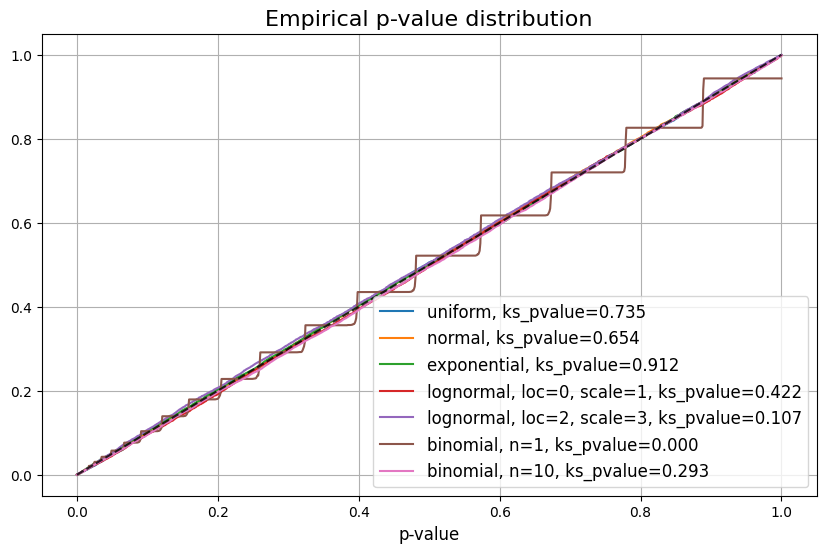

In [5]:
sample_size = 100
n_experiments = 10000

pvalues_dict = defaultdict(list)
datagen_dict = {
    "uniform": np.random.uniform,
    "normal": np.random.normal,
    "exponential": np.random.exponential,
    "lognormal, loc=0, scale=1": np.random.lognormal,
    "lognormal, loc=2, scale=3": lambda size: np.random.lognormal(2, 3, size=size),
    "binomial, n=1": lambda size: np.random.binomial(1, 0.5, size=size),
    "binomial, n=10": lambda size: np.random.binomial(10, 0.5, size=size),
}

for name, datagen_fn in datagen_dict.items():
    a = datagen_fn(size=(n_experiments, sample_size))
    b = datagen_fn(size=(n_experiments, sample_size))
    for a_sample, b_sample in zip(a, b):
        t, p = stats.mannwhitneyu(a_sample, b_sample)
        pvalues_dict[name].append(p)

plot_pvalue_distribution(pvalues_dict, test_mode=False)

Из графиков видно, что критерий Манна-Уитни более корректно работает на данных из логнормального и экспоненциального распределений, но также, как и критерий Стьюдента, показывает некорректные результаты на данных из распределения Бернулли.

Эти отличия могут быть объяснены природой критерия - сравнивать относительные расположения отдельных элементов в выборках, а не их значения, поэтому нестабильные выбросы в логнормальном и экспоненциальном не так сильно влияют на результаты критерия

#### Пункт 2

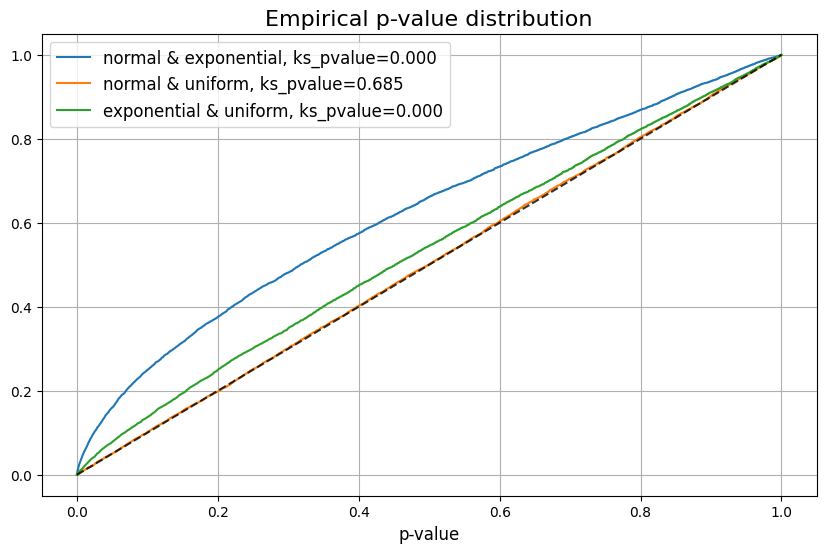

In [6]:
pvalues_dict = defaultdict(list)
# mean=1, var=1 for each distribution
datagen_dict = {
    "normal": lambda size: np.random.normal(1, 1, size=size),
    "exponential": lambda size: np.random.exponential(
        1, size=size
    ),  # mean=1/lambda, var=1/lambda^2
    "uniform": lambda size: np.random.uniform(
        1 - np.sqrt(3), 1 + np.sqrt(3), size=size
    ),  # mean=(a+b)/2, var=(b-a)^2/12
}

for name1, name2 in combinations(datagen_dict.keys(), 2):
    a = datagen_dict[name1](size=(n_experiments, sample_size))
    b = datagen_dict[name2](size=(n_experiments, sample_size))
    for a_sample, b_sample in zip(a, b):
        t, p = stats.mannwhitneyu(a_sample, b_sample)
        pvalues_dict[f"{name1} & {name2}"].append(p)

plot_pvalue_distribution(pvalues_dict, test_mode=False)

Критерий Манна-Уитни некорректно работает на данных с одинаковыми средними и дисперсиями, но из разных распределений, в отличие от критерия Стьюдента

Это может быть вызвано тем, что критерий Манна-Уитни основывается на относительных наблюдений из выборок, а не на самих значениях, поэтому отличия в геометриях распределений (например, данные из экспоненциального распределения не ограничены в отличие от равномерного) могут понизить уверенность критерия

#### Пункт 3

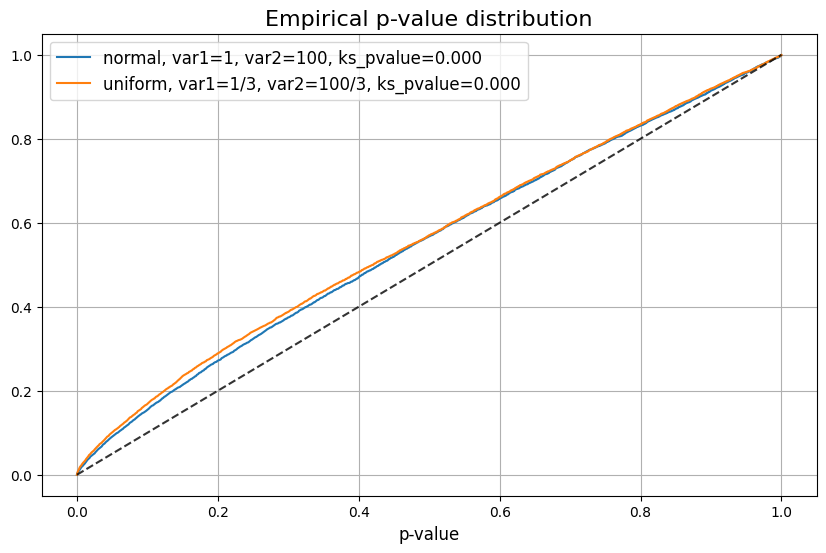

In [7]:
pvalues_dict = defaultdict(list)
datagen_dict = {
    "normal, var1=1, var2=100": (
        lambda size: np.random.normal(0, 1, size=size),
        lambda size: np.random.normal(0, 10, size=size),
    ),
    "uniform, var1=1/3, var2=100/3": (
        lambda size: np.random.uniform(-1, 1, size=size),
        lambda size: np.random.uniform(-10, 10, size=size),
    ),
}

for name, (datagen1, datagen2) in datagen_dict.items():
    a = datagen1(size=(n_experiments, sample_size))
    b = datagen2(size=(n_experiments, sample_size))
    for a_sample, b_sample in zip(a, b):
        t, p = stats.mannwhitneyu(a_sample, b_sample)
        pvalues_dict[name].append(p)

plot_pvalue_distribution(pvalues_dict, test_mode=False)

График показывает, что как и критерий Стьюдента, критерий Манна-Уитни некорректно работает на данных из одного распределения с одинаковыми средними и разными дисперсиями

#### Пункт 4

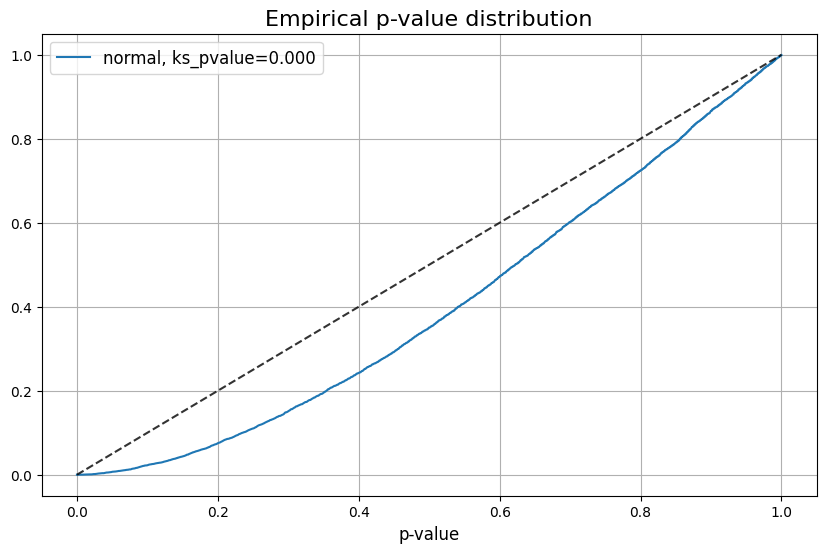

In [8]:
pvalues_dict = defaultdict(list)

mu = [0, 0]
sigma = [[1, 0.5], [0.5, 1]]
a, b = np.random.multivariate_normal(
    mu, sigma, size=(n_experiments, sample_size)
).transpose(2, 0, 1)

for a_sample, b_sample in zip(a, b):
    t, p = stats.mannwhitneyu(a_sample, b_sample)
    pvalues_dict["normal"].append(p)

plot_pvalue_distribution(pvalues_dict, test_mode=False)

Также, как и критерий Стьюдента, критерий Манна-Уитни некорректно работает на зависимых данных